# Component-based MOEA/D: configuration examples

This notebook illustrates `jmetal.component`'s component-based MOEA/D
(`build_moead()`/`build_moead_de()`) across the configurations exercised by this project's
tests and examples under `examples/component/`:

1. Default settings (classic, SBX) on ZDT4
2. Default settings (classic, SBX) on DTLZ1
3. Default settings (classic, SBX) on DTLZ2
4. MOEA/D-DE default settings on ZDT4
5. MOEA/D-DE default settings on DTLZ1
6. MOEA/D-DE on DTLZ1 with an unbounded external archive
7. MOEA/D-DE default settings on DTLZ2
8. The observer pattern: watching a MOEA/D-DE front evolve on LZ09_F2

MOEA/D is architecturally different from NSGA-II/SMS-EMOA (see
[`notebooks/NSGAIIComponentBased.ipynb`](NSGAIIComponentBased.ipynb) and
[`notebooks/SMSEMOAComponentBased.ipynb`](SMSEMOAComponentBased.ipynb)): it processes one
subproblem per iteration, using a weight vector per subproblem and a neighborhood structure
to guide search, rather than a whole population/offspring batch. Both factories still build
on the exact same `EvolutionaryAlgorithm` template as NSGA-II/SMS-EMOA -- the `MOEADContext`
mechanism that makes this fit without changing the template is explained in
[`docs/advanced-topics/component-architecture.md`](../docs/advanced-topics/component-architecture.md#building-moead).

Two variants are provided: `build_moead()` (classic -- any crossover/mutation pair, SBX
here, defaulting to `PenaltyBoundaryIntersection` aggregation) and `build_moead_de()`
(differential-evolution crossover, defaulting to `Tschebycheff` aggregation) -- the
combination jMetalPy's existing, non-component `MOEAD` class actually implements, despite
its plain name (see `MODERNIZATION.md` for the full story, including a cross-check against
jMetal Java's own legacy `MOEAD.java`, which turns out to have the identical situation).

**On reproducibility.** Unlike NSGA-II/SMS-EMOA, every MOEA/D-specific random decision here
draws exclusively from the `rng` passed to the two factories -- never the global
`random`/`numpy.random` state -- so every run below is reproducible from its one fixed seed
alone, with no `random.seed()` call anywhere in this notebook (see `MODERNIZATION.md` for
why the classic, non-component `MOEAD` cannot offer the same guarantee).

Each section shows the final front against its reference front and reports three quality
indicators: hypervolume, IGD+, and the additive epsilon indicator (the last two delegate to
[moocore](https://multi-objective.github.io/moocore/python/) for the actual computation).


In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt

from jmetal.component.algorithm.multiobjective.moead import build_moead, build_moead_de
from jmetal.component.catalogue.common.termination import TerminationByEvaluations
from jmetal.core.quality_indicator import (
    AdditiveEpsilonIndicator,
    HyperVolume,
    InvertedGenerationalDistancePlus,
)
from jmetal.lab.visualization import Plot
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.problem import DTLZ1, DTLZ2, LZ09_F2, ZDT4
from jmetal.util.archive import NonDominatedSolutionsArchive
from jmetal.util.solution import get_non_dominated_solutions, read_solutions


### A small helper to report indicator values

Each section below builds a front, then compares it against the problem's reference front using
three indicators. This helper keeps that repeated bit of code in one place.


In [2]:
def report_indicators(front, reference_solutions, reference_point):
    front_array = np.array([solution.objectives for solution in front])
    reference_array = np.array([solution.objectives for solution in reference_solutions])

    hypervolume = HyperVolume(reference_point=reference_point)
    igd_plus = InvertedGenerationalDistancePlus(reference_array)
    epsilon = AdditiveEpsilonIndicator(reference_array)

    print(f"Front size:        {len(front)}")
    print(f"Hypervolume:       {hypervolume.compute(front_array):.4f}")
    print(f"IGD+:              {igd_plus.compute(front_array):.4f}")
    print(f"Additive epsilon:  {epsilon.compute(front_array):.4f}")


## 1. Default settings (classic) on ZDT4

`build_moead()` accepts any crossover/mutation pair -- SBX and polynomial mutation here,
the usual choice -- unlike jMetalPy's existing, non-component `MOEAD` class, which is
already MOEA/D-DE and requires a `DifferentialEvolutionCrossover` specifically. ZDT4 is
multi-modal (many local Pareto fronts); a 2-objective problem, so its weight vectors are
generated analytically and no weight-vector file is needed. See
[`examples/component/moead_default_zdt4.py`](../examples/component/moead_default_zdt4.py).


In [3]:
seed = 1
problem = ZDT4()
reference_front = read_solutions(filename="../resources/reference_fronts/ZDT4.pf")

algorithm = build_moead(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=25000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 1.42s


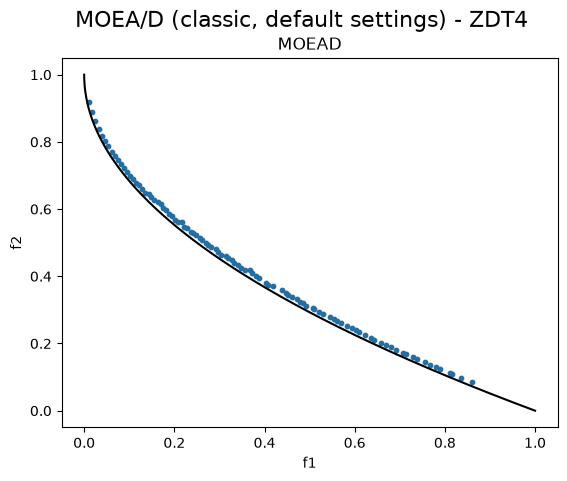

In [4]:
plot_front = Plot(
    title=f"MOEA/D (classic, default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2"],
)
plot_front.plot(front, label=algorithm.get_name())


In [5]:
report_indicators(front, reference_front, reference_point=[1, 1])

Front size:        97
Hypervolume:       0.6409
IGD+:              0.0179
Additive epsilon:  0.0857


## 2. Default settings (classic) on DTLZ1

`population_size=91` matches a weight-vector file already bundled in
`resources/MOEAD_weights/` (`W3D_91.dat`). DTLZ1's Pareto front is a flat hyperplane
reachable through `11^k - 1` local optima. See
[`examples/component/moead_default_dtlz1.py`](../examples/component/moead_default_dtlz1.py).


In [6]:
seed = 1
problem = DTLZ1()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ1.3D.pf")

algorithm = build_moead(
    problem,
    population_size=91,
    weight_files_path="../resources/MOEAD_weights",
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 2.86s


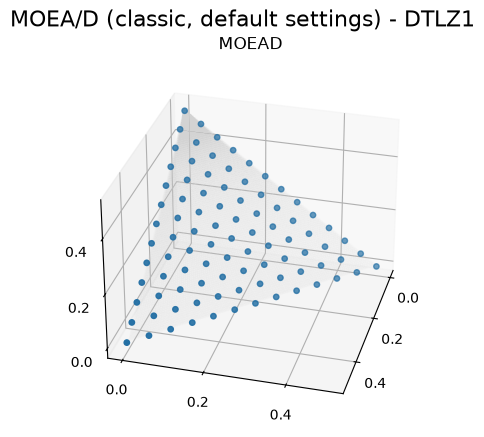

In [7]:
plot_front = Plot(
    title=f"MOEA/D (classic, default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [8]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        91
Hypervolume:       0.9736
IGD+:              0.0147
Additive epsilon:  0.0278


## 3. Default settings (classic) on DTLZ2

`population_size=91` matches the same bundled weight-vector file as DTLZ1's section.
DTLZ2's Pareto front is a smooth, convex/spherical octant -- a comparatively easy
3-objective convergence test. See
[`examples/component/moead_default_dtlz2.py`](../examples/component/moead_default_dtlz2.py).


In [9]:
seed = 1
problem = DTLZ2()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ2.3D.pf")

algorithm = build_moead(
    problem,
    population_size=91,
    weight_files_path="../resources/MOEAD_weights",
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 3.10s


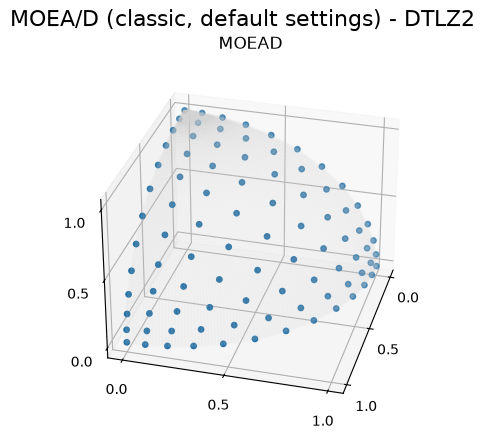

In [10]:
plot_front = Plot(
    title=f"MOEA/D (classic, default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [11]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        91
Hypervolume:       0.4137
IGD+:              0.0230
Additive epsilon:  0.0792


## 4. MOEA/D-DE default settings on ZDT4

`build_moead_de()` constructs its own `DifferentialEvolutionCrossover` from `cr`/`f`
(defaults `1.0`/`0.5`) -- this is the combination jMetalPy's existing, non-component
`MOEAD` class actually implements.

**A real, calibrated finding, not just a note.** At the same 25000-evaluation budget as
section 1's classic/SBX run, MOEA/D-DE on ZDT4 landed around HV=0.31-0.48 across a few
seeds during development -- well below SBX's ~0.64. Doubling the budget to 50000
evaluations closes that gap almost entirely. This isn't a MOEA/D bug -- SBX's stronger
exploration on this specific multi-modal landscape is a known property of the operator,
not of the algorithm. See
[`examples/component/moead_de_default_zdt4.py`](../examples/component/moead_de_default_zdt4.py).


In [12]:
seed = 1
problem = ZDT4()
reference_front = read_solutions(filename="../resources/reference_fronts/ZDT4.pf")

algorithm = build_moead_de(
    problem,
    population_size=100,
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=50000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 1.52s


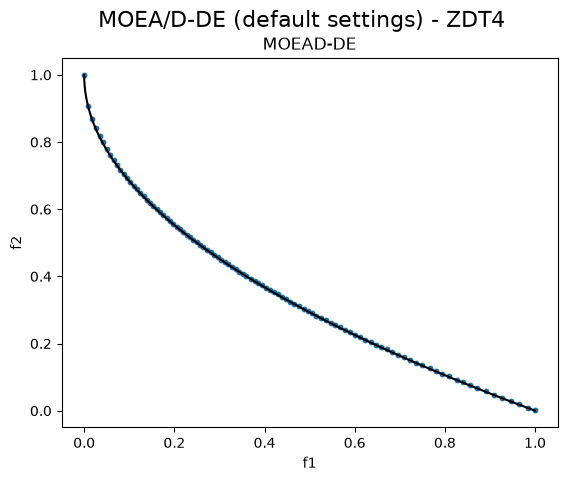

In [13]:
plot_front = Plot(
    title=f"MOEA/D-DE (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2"],
)
plot_front.plot(front, label=algorithm.get_name())


In [14]:
report_indicators(front, reference_front, reference_point=[1, 1])

Front size:        100
Hypervolume:       0.6602
IGD+:              0.0032
Additive epsilon:  0.0084


## 5. MOEA/D-DE default settings on DTLZ1

`population_size=91`, same weight-vector file as sections 2-3. See
[`examples/component/moead_de_default_dtlz1.py`](../examples/component/moead_de_default_dtlz1.py).


In [15]:
seed = 1
problem = DTLZ1()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ1.3D.pf")

algorithm = build_moead_de(
    problem,
    population_size=91,
    weight_files_path="../resources/MOEAD_weights",
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 1.38s


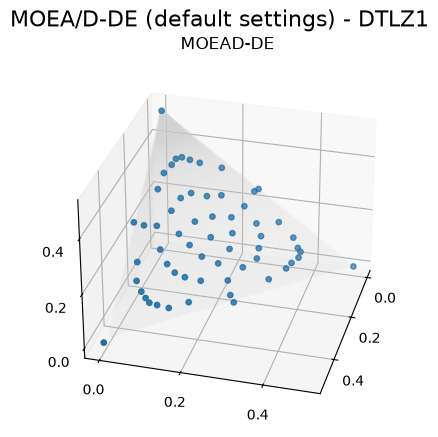

In [16]:
plot_front = Plot(
    title=f"MOEA/D-DE (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [17]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        61
Hypervolume:       0.9668
IGD+:              0.0235
Additive epsilon:  0.0544


## 6. MOEA/D-DE on DTLZ1 with an unbounded external archive

Section 5's result above is a real, visible gap, not just a number to accept at face
value: `Front size: 61` out of `population_size=91` -- 30 of the population's slots
hold solutions `get_non_dominated_solutions()` throws away as dominated. DTLZ1's flat,
degenerate Pareto front makes this easy to trigger: several weight vectors can end up
converging to similar or dominated points, wasting population slots that could
otherwise hold distinct, non-dominated solutions.

Like `build_nsgaii()`/`build_smsemoa()`, `build_moead_de()` accepts `archive=` for
free -- same mechanism, no MOEA/D-specific code needed. An unbounded
`NonDominatedSolutionsArchive` accumulates every non-dominated solution ever
evaluated, independently of what the population/replacement strategy currently holds;
`result()` then reduces it back to `population_size` via distance-based subset
selection. Same settings as section 5 otherwise (`population_size=91`, 40000
evaluations, same seed) -- the only difference is `archive=`.

Section 7 below shows the same gap on DTLZ2 (`Front size: 65` out of 91) -- the fix is
identical; see
[`examples/component/moead_de_unbounded_archive_dtlz2.py`](../examples/component/moead_de_unbounded_archive_dtlz2.py)
rather than repeating this section for it.


In [18]:
seed = 1
problem = DTLZ1()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ1.3D.pf")

archive = NonDominatedSolutionsArchive()
algorithm = build_moead_de(
    problem,
    population_size=91,
    weight_files_path="../resources/MOEAD_weights",
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
    archive=archive,
)
algorithm.run()

front = algorithm.result()  # archive, reduced to population_size via subset selection
print(f"Computing time: {algorithm.total_computing_time:.2f}s")
print(f"Archive size (before reduction): {len(archive.solution_list)}")
print(f"Result size (after reduction):   {len(front)}")


Computing time: 15.30s
Archive size (before reduction): 4498
Result size (after reduction):   91


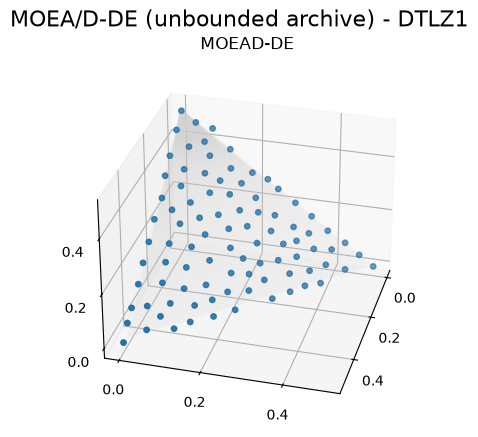

In [19]:
plot_front = Plot(
    title=f"MOEA/D-DE (unbounded archive) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [20]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        91
Hypervolume:       0.9722
IGD+:              0.0176
Additive epsilon:  0.0352


## 7. MOEA/D-DE default settings on DTLZ2

`population_size=91`, same weight-vector file as sections 2-3-5. See
[`examples/component/moead_de_default_dtlz2.py`](../examples/component/moead_de_default_dtlz2.py).


In [21]:
seed = 1
problem = DTLZ2()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ2.3D.pf")

algorithm = build_moead_de(
    problem,
    population_size=91,
    weight_files_path="../resources/MOEAD_weights",
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 1.52s


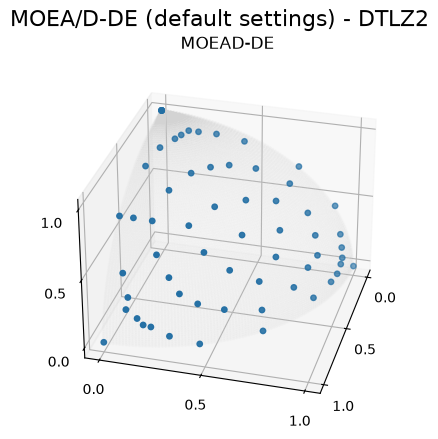

In [22]:
plot_front = Plot(
    title=f"MOEA/D-DE (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [23]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        65
Hypervolume:       0.3733
IGD+:              0.0351
Additive epsilon:  0.1011


## 8. The observer pattern: watching a MOEA/D-DE front evolve on LZ09_F2

Every component-based algorithm exposes `algorithm.observable`, the same observer hook the
classic algorithms use. On every generation it notifies registered observers with the exact
`"PROBLEM"`/`"EVALUATIONS"`/`"SOLUTIONS"`/`"COMPUTING_TIME"` keys `AlgorithmState.as_dict()`
produces -- so every observer in `jmetal.util.observer` (`VisualizerObserver`,
`ProgressBarObserver`, `WriteFrontToFileObserver`, ...) already works against it unchanged.
[`examples/component/moead_de_lz09_f2.py`](../examples/component/moead_de_lz09_f2.py) runs
this exact configuration (population 100, 175000 evaluations) without an observer at all.

A small custom observer, same one the NSGA-II/SMS-EMOA notebooks use, does the job here
instead: it records a copy of the front's objectives the first time the evaluation count
reaches each of a list of checkpoints, so the front's evolution can be plotted -- as a static
grid, not a live-updating window -- once the run finishes. MOEA/D-DE is steady-state (one
offspring evaluated per generation), so this notifies -- and can snapshot -- at every single
generation.


In [24]:
class FrontSnapshotObserver:
    """Collects a copy of the front's objectives at a set of evaluation checkpoints."""

    def __init__(self, checkpoints):
        self.pending_checkpoints = sorted(checkpoints)
        self.snapshots = {}

    def update(self, *args, **kwargs):
        evaluations = kwargs["EVALUATIONS"]
        solutions = kwargs["SOLUTIONS"]

        while self.pending_checkpoints and evaluations >= self.pending_checkpoints[0]:
            checkpoint = self.pending_checkpoints.pop(0)
            self.snapshots[checkpoint] = np.array([s.objectives for s in solutions])


In [25]:
seed = 1
problem = LZ09_F2()
reference_front = read_solutions(filename="../resources/reference_fronts/LZ09_F2.pf")
# LZ09_F2.pf's points aren't ordered along the front, unlike ZDT4's/ZDT1's -- sort by
# f1 so plotting it as a line below draws a curve instead of a scribble.
reference_array = np.array([s.objectives for s in reference_front])
reference_array = reference_array[reference_array[:, 0].argsort()]

checkpoints = [100, 2000, 10000, 40000, 100000, 175000]
snapshot_observer = FrontSnapshotObserver(checkpoints)

algorithm = build_moead_de(
    problem,
    population_size=100,
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=175000),
    rng=np.random.default_rng(seed),
)
algorithm.observable.register(observer=snapshot_observer)
algorithm.run()

print(f"Collected {len(snapshot_observer.snapshots)} snapshots")
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Collected 6 snapshots
Computing time: 8.28s


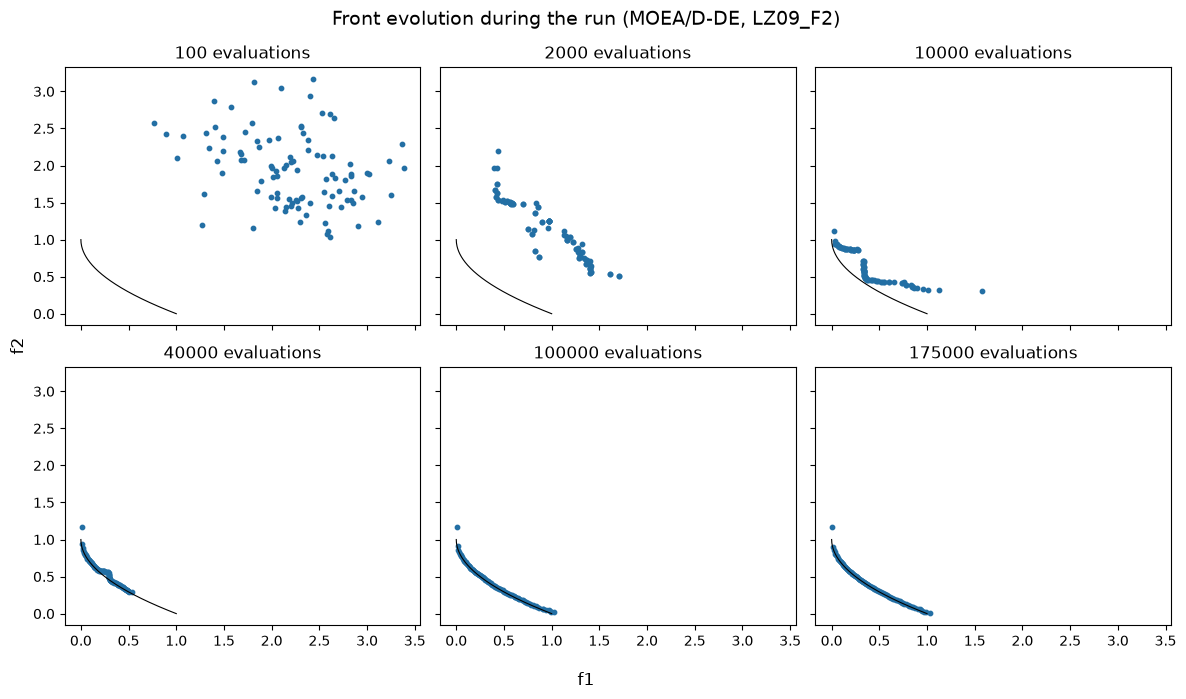

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
fig.suptitle("Front evolution during the run (MOEA/D-DE, LZ09_F2)", fontsize=14)

for ax, checkpoint in zip(axes.flat, checkpoints):
    snapshot = snapshot_observer.snapshots[checkpoint]
    ax.plot(reference_array[:, 0], reference_array[:, 1], color="black", linewidth=0.8)
    ax.scatter(snapshot[:, 0], snapshot[:, 1], color="#236FA4", s=10)
    ax.set_title(f"{checkpoint} evaluations")

fig.supxlabel("f1")
fig.supylabel("f2")
plt.tight_layout()
plt.show()


In [27]:
report_indicators(get_non_dominated_solutions(algorithm.result()), reference_front, reference_point=[1, 1])

Front size:        100
Hypervolume:       0.6538
IGD+:              0.0070
Additive epsilon:  0.0191
